In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

# ---------------------- CUSTOM PARAMETERS ----------------------
ATTN_PATH = "data/adamson/SOCS1_delta_attn.npy"
CSV_PATH = "data/adamson/SOCS1_delta.csv"
H5AD_PATH = "data/adamson/control.h5ad"
SAVE_PATH = "images/SOCS1_heatmap_abs.png"

PERTURB_GENE = "SOCS1"
TOP_N_GENES = 20
PERCENTILE_VMAX = 95
VMIN_VALUE = 0

PLOT_FIGSIZE = (10, 8)
DPI_VALUE = 300
CMAP_NAME = "Blues"
TITLE_FONT_SIZE = 14
COLORBAR_SHRINK = 0.6

In [2]:
delta_attn = np.load(ATTN_PATH)
adata = sc.read_h5ad(H5AD_PATH)
gene_names = list(adata.var['gene_name'])

In [3]:
df = pd.read_csv(CSV_PATH)
df = df.sort_values(by="importance", ascending=False)
top_genes = df['target'].head(TOP_N_GENES).tolist()

In [4]:
gene_to_idx = {g: i for i, g in enumerate(gene_names)}

if PERTURB_GENE not in gene_to_idx:
    raise ValueError(f"{PERTURB_GENE} not found in gene list")

perturb_idx = gene_to_idx[PERTURB_GENE] + 1
valid_genes = [g for g in top_genes if g in gene_to_idx]

indices = [perturb_idx] + [gene_to_idx[g] + 1 for g in valid_genes]
labels = [PERTURB_GENE] + valid_genes

print("Final number of genes:", len(labels))

Final number of genes: 21


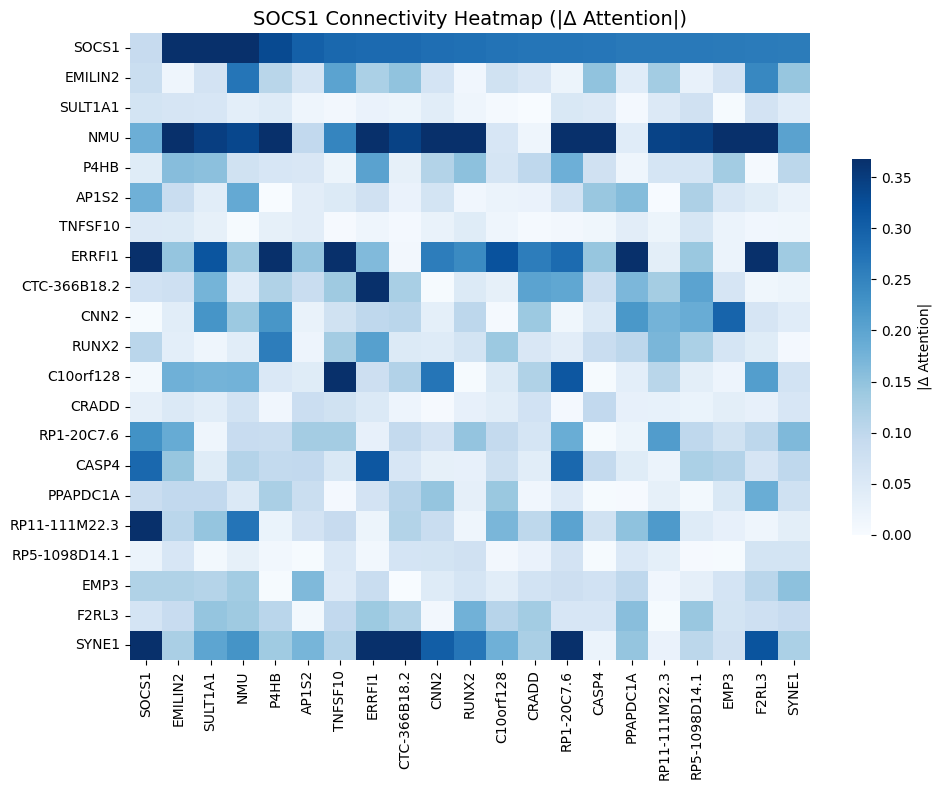

In [5]:
sub_attn = delta_attn[np.ix_(indices, indices)]
sub_attn_abs = np.abs(sub_attn)
vmax = np.percentile(sub_attn_abs, PERCENTILE_VMAX)

plt.figure(figsize=PLOT_FIGSIZE)

sns.heatmap(
    sub_attn_abs,
    cmap=CMAP_NAME,
    vmin=VMIN_VALUE,
    vmax=vmax,
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0,
    cbar_kws={
        "shrink": COLORBAR_SHRINK,
        "label": "|Δ Attention|"
    }
)

plt.title("SOCS1 Connectivity Heatmap (|Δ Attention|)", fontsize=TITLE_FONT_SIZE)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=DPI_VALUE)
plt.show()
plt.close()

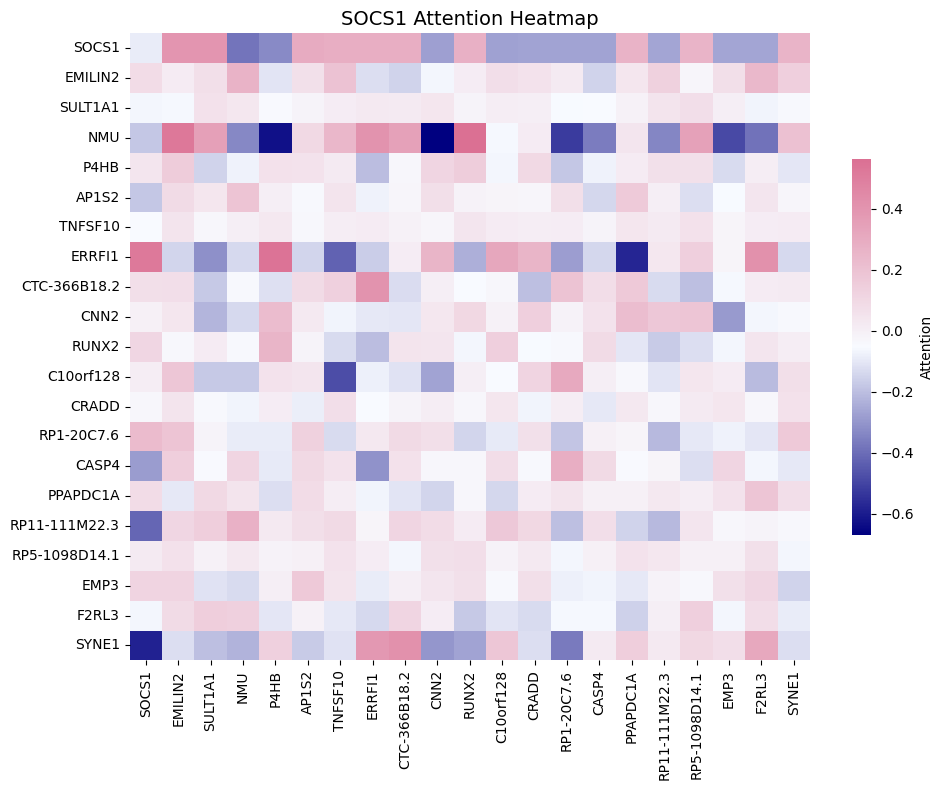

In [6]:
from matplotlib.colors import LinearSegmentedColormap

plt.figure(figsize=PLOT_FIGSIZE)

custom_cmap = LinearSegmentedColormap.from_list(
    "light_blue_pink",
    ["#000080", "#F8FBFF", "#DB7093"]
)


sns.heatmap(
    sub_attn,
    cmap=custom_cmap,

    xticklabels=labels,
    yticklabels=labels,
    linewidths=0,
    cbar_kws={
        "shrink": COLORBAR_SHRINK,
        "label": "Attention"
    }
)

plt.title("SOCS1 Attention Heatmap", fontsize=TITLE_FONT_SIZE)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('images/2.png', dpi=DPI_VALUE)
plt.show()
plt.close()